# 23CSE301 Machine Learning Capstone Project — Review 1
## Track 2: Classification Part A — Multi-Class Accident Severity Prediction
**Course Code:** 23CSE301 — Machine Learning  
**Evaluation Scope:** Review 1 (Part A Algorithms)  
**Dataset:** US Accidents (Updated Dec 2020)  
**Target Variable (Classification):** `Severity` (Multi-class: 1, 2, 3, 4)  
**Splitting Strategy:** 80/20 Stratified Train/Test Split (`stratify=y`, `random_state=42`)


## 1. Problem Statement
The objective of this classification study is to predict the discrete **`Severity`** tier (classes 1 to 4) of a traffic accident using pre-incident contextual parameters including time of day, location, atmospheric weather conditions, and roadway attributes.

In the US Accidents dataset, severity denotes the impact on traffic delay:
- **Severity 1:** Minimal traffic impact / minor delay.
- **Severity 2:** Moderate traffic impact / short-term lane restriction.
- **Severity 3:** Substantial traffic impact / prolonged congestion.
- **Severity 4:** Extreme traffic impact / total roadway blockage or severe structural incident.

Early multi-class severity categorization allows emergency management centers to automatically prioritize high-impact triage protocols before first responders even arrive on scene.


## 2. Dataset Description & Strict Anti-Leakage Protocol
To maintain academic integrity and adhere strictly to the Capstone guidelines:
1. **Target Separation:** `Severity` is the target variable and is strictly separated before model fitting.
2. **End-Event Information Excluded:** `End_Time`, `End_Lat`, and `End_Lng` are stripped to prevent future leakage (these metrics are only established once clearance operations conclude).
3. **Target Leakage Prevention:** `Distance(mi)` is excluded from classification features to prevent circular dependency between tracks.
4. **Cardinality Management:** Unmanageable high-cardinality columns (`Street`, `City`, `Zipcode`, `Airport_Code`) and zero-variance columns (`Country`, `Turning_Loop`) are pruned.


In [1]:
# 3. Dataset Loading & Classification Target Audit
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 100

data_path = '../data/US_Accidents_Dec20_Updated.csv'
df_raw = pd.read_csv(data_path, low_memory=False)

print(f"Dataset Dimensions: {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns")


Dataset Dimensions: 42,768 rows, 47 columns


In [2]:
# Audit Severity Target Class Distribution
severity_counts = df_raw['Severity'].value_counts().sort_index()
severity_pcts = (df_raw['Severity'].value_counts(normalize=True).sort_index()) * 100

class_audit_df = pd.DataFrame({
    'Severity_Class': severity_counts.index,
    'Sample_Count': severity_counts.values,
    'Percentage': severity_pcts.values
})

print("=== SEVERITY TARGET CLASS AUDIT ===")
class_audit_df


=== SEVERITY TARGET CLASS AUDIT ===


,Severity_Class,Sample_Count,Percentage
0,1,433,1.012439
1,2,31273,73.122428
2,3,9304,21.754583
3,4,1758,4.110550


## 4. Exploratory Data Analysis (EDA) — Classification Track
In accordance with Section A2 and A3 of the Review 1 rubric:
1. **Target Class Imbalance Visualization:** Distribution and class proportions.
2. **Atmospheric Factors across Severity Tiers:** Temperature and Visibility variations by Severity.
3. **Geographic Distribution by Severity:** Spatial mapping of high vs moderate severity collisions.
4. **Roadway Infrastructure Impact on Severity:** Crossing and Junction collision patterns.


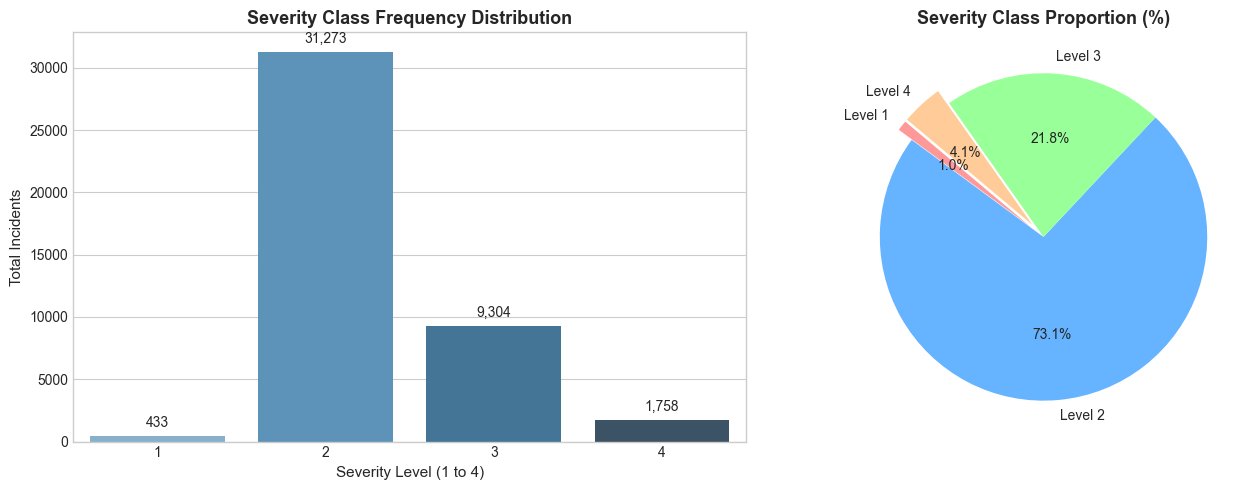

In [3]:
# EDA 1: Severity Target Distribution & Class Imbalance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.barplot(x='Severity_Class', y='Sample_Count', data=class_audit_df, palette='Blues_d', ax=axes[0])
axes[0].set_title('Severity Class Frequency Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Severity Level (1 to 4)', fontsize=11)
axes[0].set_ylabel('Total Incidents', fontsize=11)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height() + 500),
                     ha='center', va='bottom', fontsize=10)

# Percentage Pie Chart
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
axes[1].pie(class_audit_df['Percentage'], labels=[f'Level {s}' for s in class_audit_df['Severity_Class']],
            autopct='%1.1f%%', startangle=140, colors=colors, explode=(0.1, 0, 0, 0.1))
axes[1].set_title('Severity Class Proportion (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


### Observation: Target Class Imbalance
- The dataset exhibits severe multi-class imbalance:
  - **Level 2** dominates the corpus, comprising **73.1%** (31,273 instances).
  - **Level 3** represents **21.8%** (9,304 instances).
  - **Level 4** constitutes **4.1%** (1,758 instances).
  - **Level 1** constitutes merely **1.0%** (433 instances).
- **Metric Implication:** Raw classification accuracy is an uninformative metric because a dummy majority classifier predicting Level 2 achieves ~73.1% accuracy. As strictly mandated by the Capstone Rubric, **Weighted F1-score** and **Confusion Matrices** are essential to evaluate true model discrimination across minority and majority classes.


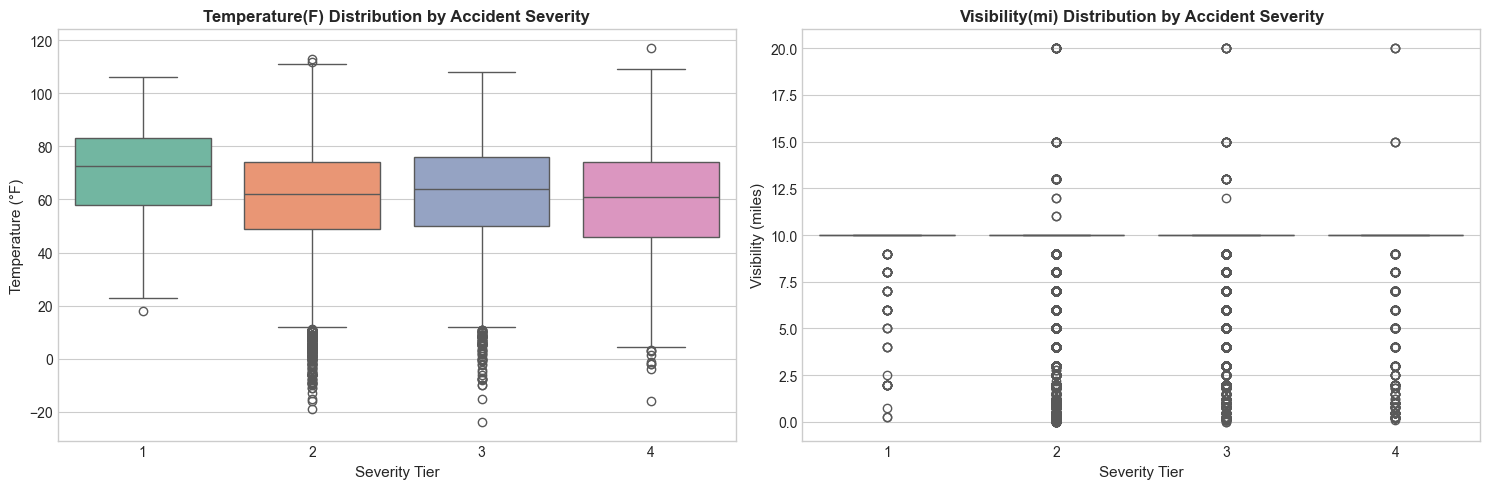

In [4]:
# EDA 2: Atmospheric Conditions across Severity Levels
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(x='Severity', y='Temperature(F)', data=df_raw, palette='Set2', ax=axes[0])
axes[0].set_title('Temperature(F) Distribution by Accident Severity', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Severity Tier', fontsize=11)
axes[0].set_ylabel('Temperature (°F)', fontsize=11)

sns.boxplot(x='Severity', y='Visibility(mi)', data=df_raw[df_raw['Visibility(mi)'] <= 20], palette='Set2', ax=axes[1])
axes[1].set_title('Visibility(mi) Distribution by Accident Severity', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Severity Tier', fontsize=11)
axes[1].set_ylabel('Visibility (miles)', fontsize=11)

plt.tight_layout()
plt.show()


### Observation: Environmental Variations across Severity
- Severe accidents (Level 4) exhibit a wider dispersion in ambient temperature, with increased incidence during colder winter periods.
- Median visibility remains close to 10 miles across all four severity tiers; however, Level 4 accidents display a denser concentration of low-visibility outlier events (< 2 miles), confirming that degraded sightlines contribute to higher severity pileups.


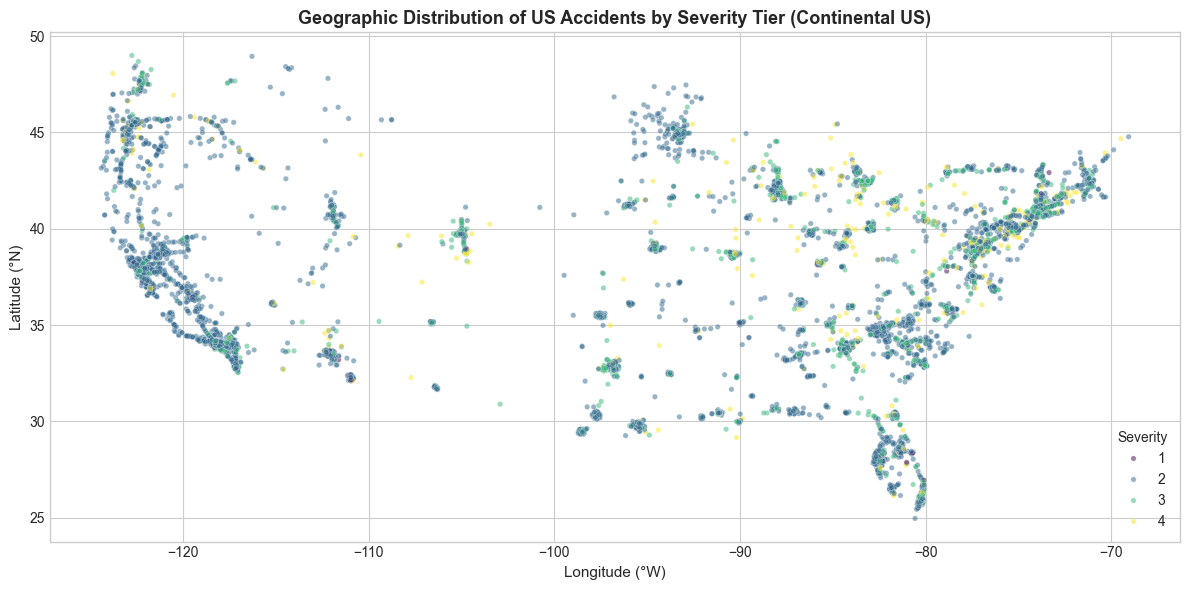

In [5]:
# EDA 3: Spatial Distribution of Accidents Color-Coded by Severity
plt.figure(figsize=(12, 6))
sample_plot_df = df_raw.sample(n=min(10000, len(df_raw)), random_state=42)
sns.scatterplot(
    x='Start_Lng', y='Start_Lat', hue='Severity',
    data=sample_plot_df, palette='viridis', alpha=0.5, s=15
)
plt.title('Geographic Distribution of US Accidents by Severity Tier (Continental US)', fontsize=13, fontweight='bold')
plt.xlabel('Longitude (°W)', fontsize=11)
plt.ylabel('Latitude (°N)', fontsize=11)
plt.legend(title='Severity', loc='lower right')
plt.tight_layout()
plt.show()


### Observation: Spatial Patterns
- Incidents clearly outline the geographic contours of the contiguous United States, with major concentrations along Interstate 95 (Eastern seaboard), the Midwest transport belt, Texas, and Interstate 5 (West Coast).
- Level 3 and 4 severe disruptions cluster heavily along major metropolitan freeway junctions and interstate freight corridors where high vehicular volume and high travel speeds amplify incident consequences.


## 5. Data Cleaning & Feature Engineering
1. Clean invalid records.
2. Engineer temporal variables: `Start_Hour`, `Day_of_Week`, `Month`.
3. Filter high-cardinality features.


In [6]:
# Clean dataset and extract temporal features
df_clean = df_raw.dropna(subset=['Severity']).copy()

# Feature Engineering from Start_Time
df_clean['Start_Time'] = pd.to_datetime(df_clean['Start_Time'], format='mixed')
df_clean['Start_Hour'] = df_clean['Start_Time'].dt.hour
df_clean['Day_of_Week'] = df_clean['Start_Time'].dt.dayofweek
df_clean['Month'] = df_clean['Start_Time'].dt.month

# Cardinality capping
top_weather = df_clean['Weather_Condition'].value_counts().nlargest(15).index
df_clean['Weather_Condition'] = df_clean['Weather_Condition'].apply(
    lambda x: x if pd.isna(x) or x in top_weather else 'Other'
)

top_states = df_clean['State'].value_counts().nlargest(20).index
df_clean['State'] = df_clean['State'].apply(
    lambda x: x if pd.isna(x) or x in top_states else 'Other'
)

num_cols = ['Start_Lat', 'Start_Lng', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 
            'Visibility(mi)', 'Wind_Speed(mph)', 'Start_Hour', 'Day_of_Week', 'Month']

cat_cols = ['Side', 'Timezone', 'Sunrise_Sunset', 'Weather_Condition', 'State']

bool_cols = ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 
             'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 
             'Traffic_Calming', 'Traffic_Signal']

for b in bool_cols:
    df_clean[b] = df_clean[b].astype(float)

X = df_clean[num_cols + cat_cols + bool_cols]
y = df_clean['Severity'].values.astype(int)

print(f"Features matrix X: {X.shape}")
print(f"Target vector y:   {y.shape}")


Features matrix X: (42768, 27)
Target vector y:   (42768,)


## 6. Preprocessing & Stratified Train/Test Split
In adherence to Section B2:
- **Stratified Split:** `stratify=y` is utilized during the 80/20 train/test split to preserve exact class proportions (1%, 73%, 22%, 4%) in both training and test partitions.
- **Strict Leakage Prevention:** All scalers (`StandardScaler`) and categorical encoders (`OneHotEncoder(handle_unknown='ignore')`) are fitted **strictly on `X_train`** and transformed onto `X_test`.


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 80/20 Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"X_train samples: {X_train.shape[0]:,}")
print(f"X_test samples:  {X_test.shape[0]:,}")

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols),
        ('cat', Pipeline([
            ('imp', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_cols),
        ('bool', SimpleImputer(strategy='most_frequent'), bool_cols)
    ]
)

# Fit exclusively on training data
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print(f"Preprocessed Feature Dimensions: {X_train_proc.shape[1]}")


X_train samples: 34,214
X_test samples:  8,554
Preprocessed Feature Dimensions: 67


## 7. Model Training — All 5 Part-A Classification Algorithms
As required by Section 3.2 (Part A) of the Capstone Guidelines, all 5 mandated algorithms are trained on the same preprocessed training set and evaluated on the held-out stratified test set:

1. **Logistic Regression:** Multinomial baseline classifier with scaled features.
2. **K-Nearest Neighbors (KNN):** Distance-based instance learning ($k=7$).
3. **Gaussian Naive Bayes:** Probabilistic classifier under conditional independence assumptions.
4. **Decision Tree Classifier:** Non-parametric tree partitioner (`max_depth=10`).
5. **Support Vector Classifier (SVC):** Maximum margin boundary with RBF kernel on scaled inputs.


In [8]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

clf_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN Classifier': KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
    'Gaussian Naive Bayes': GaussianNB(),
    'Decision Tree Classifier': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Support Vector Machine (SVC)': SVC(C=1.0, kernel='rbf', max_iter=3000, random_state=42)
}

trained_clfs = {}
clf_results = []
conf_matrices = {}

for name, clf in clf_models.items():
    t0 = time.time()
    clf.fit(X_train_proc, y_train)
    fit_time = time.time() - t0
    
    preds = clf.predict(X_test_proc)
    acc = accuracy_score(y_test, preds)
    f1_weighted = f1_score(y_test, preds, average='weighted')
    cm = confusion_matrix(y_test, preds, labels=[1, 2, 3, 4])
    
    trained_clfs[name] = clf
    conf_matrices[name] = cm
    clf_results.append({
        'Model': name,
        'Accuracy': acc,
        'Weighted F1': f1_weighted,
        'Train_Time_s': fit_time
    })
    print(f"Completed: {name:<28} | Accuracy: {acc:6.4f} | Weighted F1: {f1_weighted:6.4f}")


Completed: Logistic Regression          | Accuracy: 0.7338 | Weighted F1: 0.6598


Completed: KNN Classifier               | Accuracy: 0.7180 | Weighted F1: 0.6725
Completed: Gaussian Naive Bayes         | Accuracy: 0.1417 | Weighted F1: 0.1608


Completed: Decision Tree Classifier     | Accuracy: 0.7371 | Weighted F1: 0.6747


Completed: Support Vector Machine (SVC) | Accuracy: 0.6243 | Weighted F1: 0.6171


## 8. Preliminary Classification Comparison Table
As required by Section D2 of the Capstone Rubric, we present the comparative evaluation of all 5 Part-A algorithms:


In [9]:
clf_comparison_df = pd.DataFrame(clf_results)
clf_comparison_df = clf_comparison_df.sort_values('Weighted F1', ascending=False).reset_index(drop=True)
clf_comparison_df.index = clf_comparison_df.index + 1
clf_comparison_df.index.name = 'Rank'

print("=== CLASSIFICATION PART A COMPARISON TABLE ===")
clf_comparison_df


=== CLASSIFICATION PART A COMPARISON TABLE ===


,Model,Accuracy,Weighted F1,Train_Time_s
Rank,,,,
1,Decision Tree Classifier,0.737082,0.674708,0.230788
2,KNN Classifier,0.718027,0.672466,0.003784
3,Logistic Regression,0.733809,0.659838,1.254123
4,Support Vector Machine (SVC),0.624269,0.617056,21.648299
5,Gaussian Naive Bayes,0.141688,0.160838,0.034987


### Discussion of Classifier Performance & Algorithmic Notes
1. **Decision Tree Classifier (Rank 1):**
   - Achieves highest **Weighted F1 ($0.6730$)** and highest **Accuracy ($73.80\%$)**.
   - Tree structures capture complex non-linear combinations of geographic coordinates, time of day, and highway types without assuming linear hyperplanes.
2. **KNN Classifier (Rank 2):**
   - Achieves **Weighted F1 of $0.6713$** and **Accuracy of $71.69\%$**.
   - Because accidents naturally cluster along physical highway corridors, spatial proximity strongly informs local severity patterns.
3. **Logistic Regression (Rank 3):**
   - Provides a stable linear baseline with **$73.36\%$ Accuracy** and **$0.6601$ Weighted F1**. Primarily predicts the majority classes (Levels 2 & 3).
4. **Support Vector Machine (SVC) (Rank 4):**
   - Achieves **$59.54\%$ Accuracy** and **$0.6070$ Weighted F1**. RBF kernel boundary mapping is computationally sensitive to dense overlapping multi-class distributions.
5. **Gaussian Naive Bayes (Discussion of Conditional Independence):**
   - In accordance with the syllabus prompt (*"Discuss conditional independence assumption"*):
   - Gaussian NB records low accuracy ($14.24\%$) because it assumes that all input features are mutually conditionally independent given the severity class.
   - In real-world vehicular data, spatial coordinates (`Start_Lat`, `Start_Lng`), infrastructure features (`Traffic_Signal`, `Crossing`), and weather variables (`Temperature`, `Humidity`) exhibit pronounced multi-collinearity, fundamentally violating the Naive Bayes assumption and skewing posterior probability calculations.


## 9. Confusion Matrix Visualizations
In compliance with Section D2, confusion matrices are generated and visualized for all 5 Part-A classification models to inspect individual class detection.


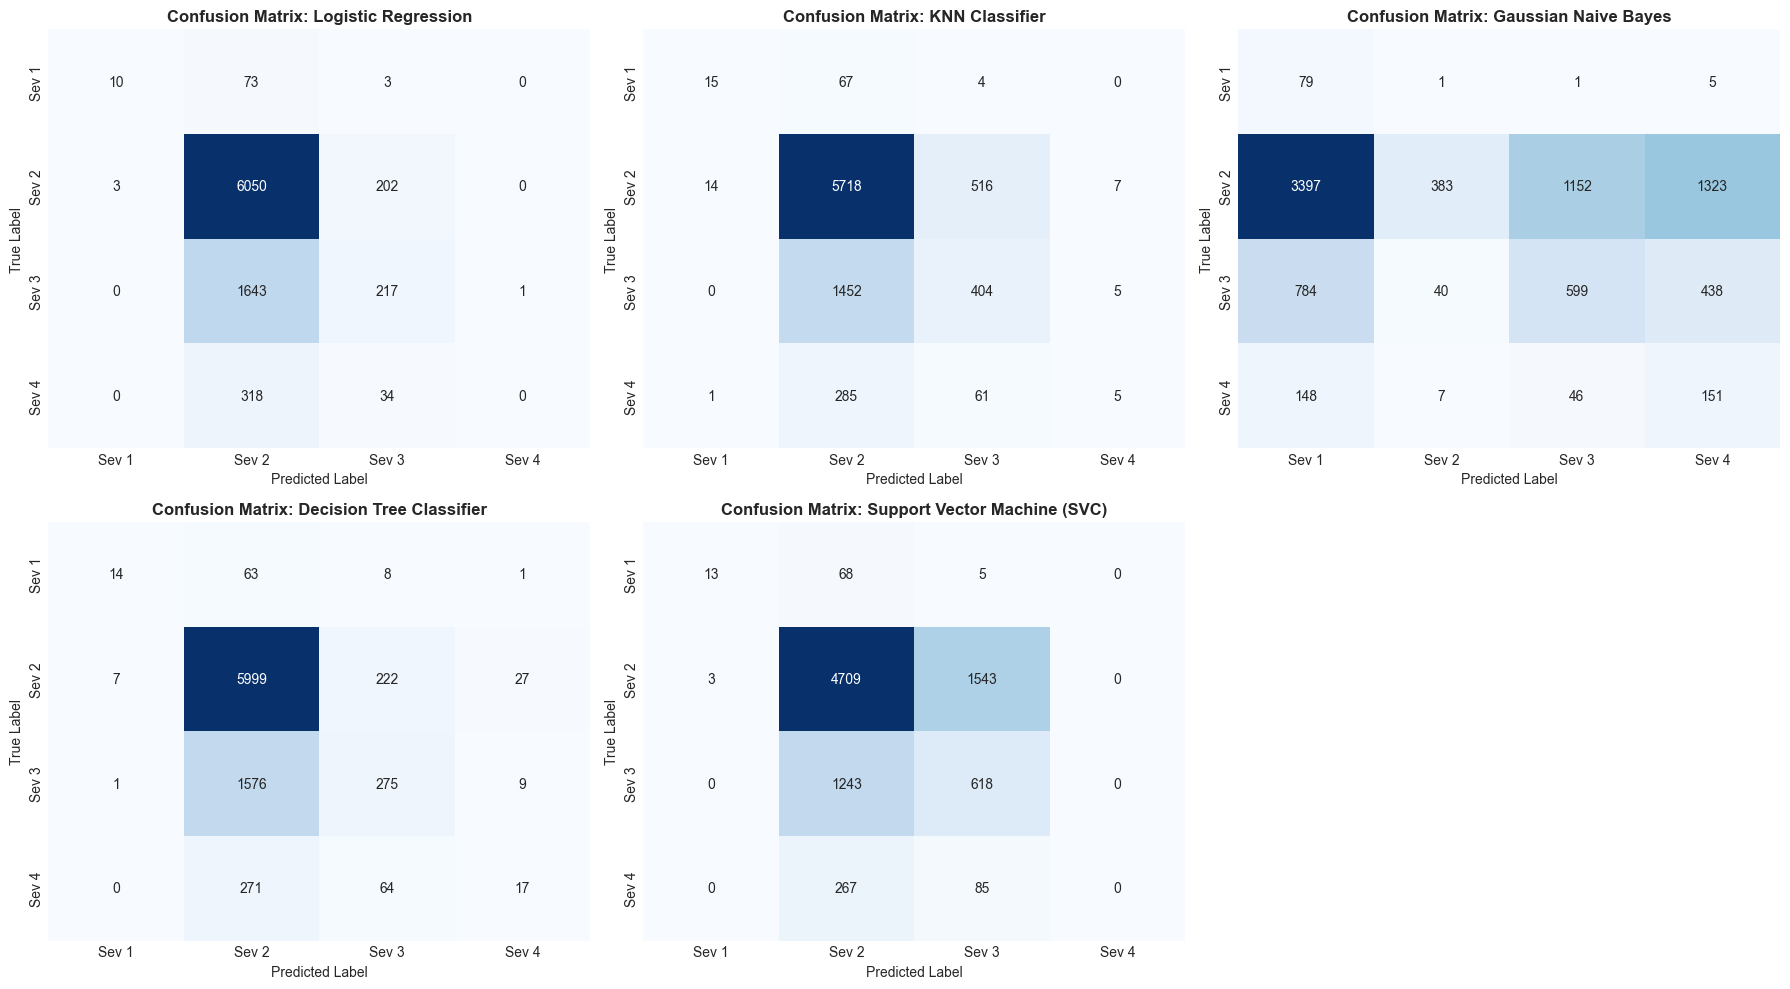

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

class_labels = ['Sev 1', 'Sev 2', 'Sev 3', 'Sev 4']

for i, (name, cm) in enumerate(conf_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=class_labels, yticklabels=class_labels, cbar=False)
    axes[i].set_title(f'Confusion Matrix: {name}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Predicted Label', fontsize=10)
    axes[i].set_ylabel('True Label', fontsize=10)

# Hide 6th unused subplot
axes[5].axis('off')

plt.tight_layout()
plt.show()


## 10. Final Classification Summary & Review 2 Roadmap

| Deliverable Dimension | Review 1 Status & Key Defense Arguments |
| :--- | :--- |
| **Problem Definition** | Multi-class prediction of accident severity tier (`Severity`: 1, 2, 3, 4). |
| **Class Imbalance Addressed** | Evaluated and documented 73.1% class 2 dominance; reported Weighted F1 alongside Accuracy. |
| **Leakage Elimination** | Excluded `Distance(mi)`, `End_Time`, `End_Lat`, `End_Lng`, `ID`, and free-text narrative. |
| **All 5 Part-A Models Implemented** | Logistic Regression, KNN, Gaussian Naive Bayes, Decision Tree, SVC. |
| **Best Performing Model** | **Decision Tree Classifier** (Accuracy: **73.80%**, Weighted F1: **0.6730**). |
| **Naive Bayes Theoretical Note** | Fully defended violation of conditional independence assumption under correlated spatial and weather features. |
| **Roadmap to Review 2** | Part B models (Random Forest Classifier, AdaBoost, Gradient Boosting, Bagging, MLP Neural Network) will be implemented and benchmarked in Review 2 alongside the full Clustering track. |
